In [1]:
### IMPORT ###
import math
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, Add, Flatten)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC
import numpy as np

2025-04-23 11:11:02.472279: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 11:11:02.472316: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 11:11:02.472954: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 11:11:02.477803: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#CHECK GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#### CONSTANTS ###
train_data_path = "../dataset_train"
test_data_path = "../dataset_test"
weigths_path = "../weights"

# Helpers function

In [19]:
### HELPERS FUNCTIONS ###

def load_image_dataset(data_path, category='art', batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.
    
    Expects the following structure:
       data_path/category/real/...
       data_path/category/fake/...
    
    Parameters:
        data_path (str): Base path for training or test dataset (e.g., "dataset_train" or "dataset_test").
        category (str): Specific category folder (default is "art").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        
    Returns:
        A tf.data.Dataset object ready for training/testing.
    """
    dataset_dir = f"{data_path}/{category}"
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_dir,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    
    Parameters:
        dataset (tf.data.Dataset): A TensorFlow dataset where each element is a (image, label) pair.
        
    Returns:
        A new tf.data.Dataset with the images scaled to [0, 1].
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

# VISUALIZE TRAINING DATA
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()
    

def plot_gradcam(model, image, class_index, last_conv_layer_name, alpha=0.4):
    """
    Generates and plots a Grad-CAM heatmap for a given image and class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels). 
               The image should be preprocessed (e.g., normalized) as needed.
        class_index: Integer index of the target class to visualize.
        last_conv_layer_name: String, name of the last convolutional layer in the model.
        alpha: Float, transparency factor for the heatmap overlay.
    """
    img_tensor = np.expand_dims(image, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(np.expand_dims(
        heatmap, axis=-1), (image.shape[0], image.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title('Original Imege')
    ax[0].axis('off')
    ax[1].imshow(image)
    ax[1].imshow(heatmap, cmap='jet', alpha=alpha)
    ax[1].set_title('Grad-CAM heatmap')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()
    

def compute_saliency_map(model, image, target_class=0):
    """
    Computes the saliency map for the given image and target class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels).
               Assumed to be preprocessed (e.g., normalized) as required by the model.
        target_class: Integer index for the target class.

    Returns:
        A NumPy array representing the saliency map.
    """
    img_tensor = tf.expand_dims(image, axis=0)
    img_tensor = tf.cast(img_tensor, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        score = preds[:, target_class]

    grads = tape.gradient(score, img_tensor)

    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency.numpy()


def display_saliency_map(model, image, target_class=0):
    """
    Computes and displays the saliency map alongside the original image.
    
    Args:
        model: Trained Keras model.
        image: A single input image as a NumPy array.
        target_class: The index of the target class.
    """
    saliency = compute_saliency_map(model, image, target_class)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency Map")
    plt.axis("off")

    plt.show()
    

# Load data

In [20]:
batch_size = 32

train_dataset,class_names = load_image_dataset(
    train_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)
train_dataset = scale_images_to_unit_range(train_dataset)
test_dataset, _ = load_image_dataset(
    test_data_path, category="art", batch_size=batch_size, img_size=(200, 200),subset_ratio=1)    
test_dataset = scale_images_to_unit_range(test_dataset)

# print the number of images in the training and validation datasets
train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()
print(f"Number of training images batch: {train_count}")
print(f"Number of validation images batch: {test_count}\n\n")

print(f"Number of training images: {train_count * batch_size}") 
print(f"Number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")


Found 86180 files belonging to 2 classes.


2025-04-21 21:42:09.621145: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:38:00.0, compute capability: 8.9


Found 21545 files belonging to 2 classes.
Number of training images batch: 2694
Number of validation images batch: 674


Number of training images: 86208
Number of validation images: 21568
Class names: ['fake', 'real']


Display some images

/tmp/ipykernel_16091/3528730878.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(labels[i].numpy())


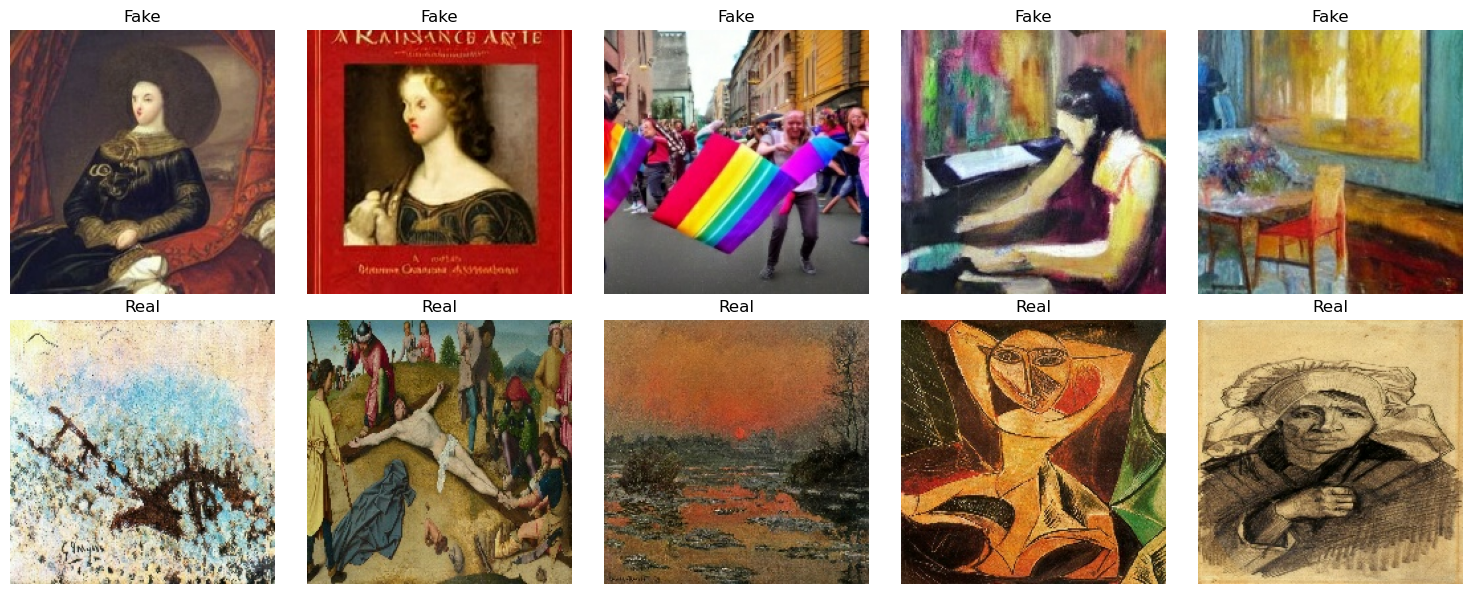

In [21]:
fake_images = []
real_images = []
num_images = 5


for images, labels in train_dataset:
    for i in range(images.shape[0]):
        # get the label value from the array
        label_index = int(labels[i].numpy())
        image = images[i].numpy()

        if class_names[label_index] == 'fake' and len(fake_images) < num_images:
            fake_images.append(image)
        elif class_names[label_index] == 'real' and len(real_images) < num_images:
            real_images.append(image)

    # break if needed
    if len(fake_images) >= num_images and len(real_images) >= num_images:
        break


fig, axes = plt.subplots(2, num_images, figsize=(15, 6))

for i in range(num_images):
    axes[0, i].imshow(fake_images[i] )
    axes[0, i].axis('off')
    axes[0, i].set_title('Fake')

    axes[1, i].imshow(real_images[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Real')

plt.tight_layout()
plt.show()

# Data augmentation

In [ ]:
### DATA AUGMENTATION ###

# TODO: Implement data augmentation if needed later

# Baseline model

Model not found, creating a new model...
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 64)        0         
 g2D)                                                            
                                                                 
 last_conv_layer (Co

2025-04-21 21:42:50.511445: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-04-21 21:42:52.550452: I external/local_xla/xla/service/service.cc:168] XLA service 0x150cb926c920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-21 21:42:52.550489: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-04-21 21:42:52.555377: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745286172.627000   13488 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2694/2694 [==============================] - ETA: 0s - loss: 0.2094 - accuracy: 0.9201 - precision: 0.9212 - recall: 0.8984 - auc: 0.9731

/shared/courseSharedFolders/142601outer/142601/cs109b/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2694/2694 [==============================] - 98s 35ms/step - loss: 0.2094 - accuracy: 0.9201 - precision: 0.9212 - recall: 0.8984 - auc: 0.9731 - val_loss: 0.0952 - val_accuracy: 0.9679 - val_precision: 0.9647 - val_recall: 0.9635 - val_auc: 0.9938
Epoch 2/10
2694/2694 [==============================] - 88s 32ms/step - loss: 0.1124 - accuracy: 0.9607 - precision: 0.9580 - recall: 0.9539 - auc: 0.9915 - val_loss: 0.1234 - val_accuracy: 0.9554 - val_precision: 0.9213 - val_recall: 0.9846 - val_auc: 0.9938
Epoch 3/10
2694/2694 [==============================] - 90s 33ms/step - loss: 0.0876 - accuracy: 0.9693 - precision: 0.9673 - recall: 0.9640 - auc: 0.9945 - val_loss: 0.0595 - val_accuracy: 0.9811 - val_precision: 0.9799 - val_recall: 0.9779 - val_auc: 0.9970
Epoch 4/10
2694/2694 [==============================] - 89s 33ms/step - loss: 0.0675 - accuracy: 0.9766 - precision: 0.9764 - recall: 0.9711 - auc: 0.9965 - val_loss: 0.0803 - val_accuracy: 0.9760 - val_precision: 0.9808 - val_reca

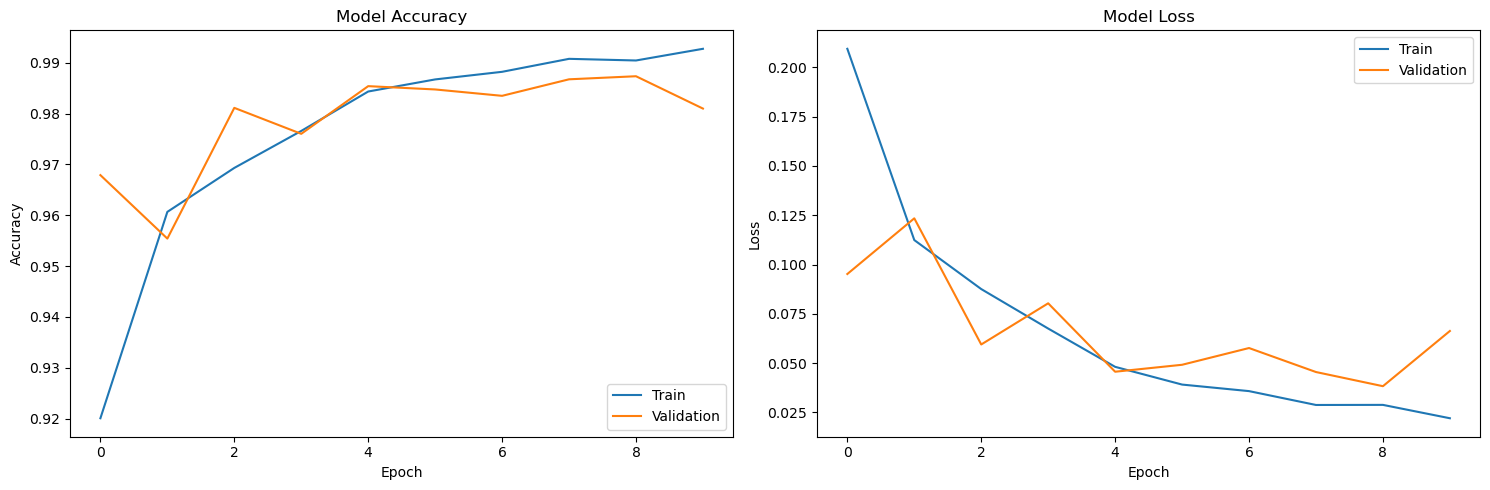

Test accuracy: 0.9810
Test precision: 0.9962
Test recall: 0.9611
Test AUC: 0.9965


In [22]:
def create_baseline_model(input_shape=(200, 200, 3)):
    inputs = Input(shape=input_shape)

    # 1st convo
    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D((2, 2))(x)

    # 2nd convo
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # 3rd convo
    x = Conv2D(128, (3, 3), activation='relu',
                      name='last_conv_layer')(x)
    x = MaxPooling2D((2, 2))(x)

    # flatten the output
    x = Flatten()(x)

    # fully connected layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    #  output layer
    outputs = layers.Dense(1, activation='sigmoid')(x)
    loss = 'binary_crossentropy'

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=loss,
        metrics=['accuracy', Precision(), Recall(), AUC()]
    )

    return model

# Check if model already exists
try:
    model = tf.keras.models.load_model(f"{weigths_path}/art_baseline_model.h5")
    print("Model loaded successfully")
except:
    print("Model not found, creating a new model...")
    model = create_baseline_model(
        input_shape=(200, 200, 3)
    )

    model.summary()

    # training
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=f"{weigths_path}/art_baseline_model.h5",
                save_best_only=True,
                monitor='val_loss',
                mode='min'
            )
        ]
    )


    # plot the training history
    plot_training_history(history)

    test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(
        test_dataset, verbose=0)
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Test precision: {test_precision:.4f}")
    print(f"Test recall: {test_recall:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    
    # save the model weights
    model.save(f"{weigths_path}/art_baseline_model.h5")

Sample image label: Fake


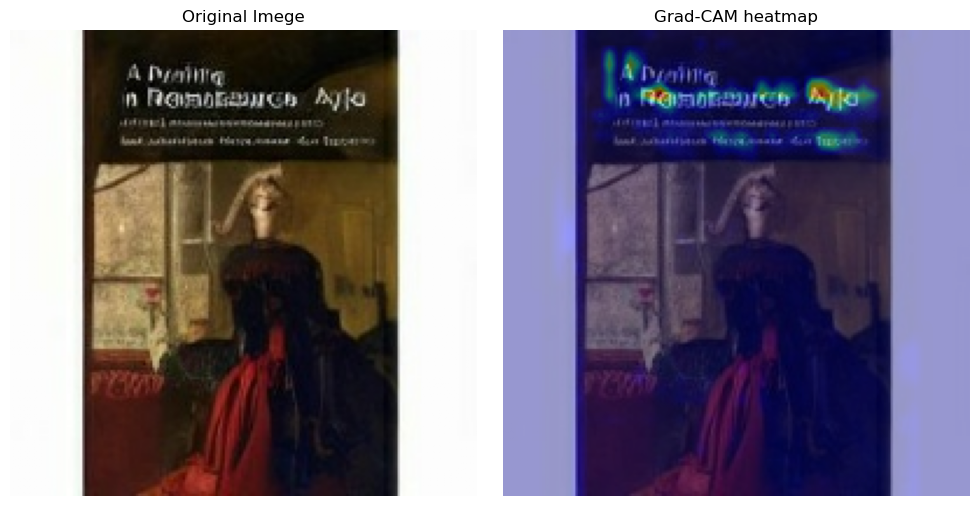

In [23]:
for images, labels in train_dataset.take(1):
    sample_image = images[0].numpy()
    sample_label = labels[0].numpy()  
    break

if sample_label == 0:
    sample_label = 'Fake'
else:
    sample_label = 'Real'
print("Sample image label:", sample_label)


target_class = 0

last_conv_layer_name = "last_conv_layer"

# Visualize the image using Grad-CAM
plot_gradcam(model, sample_image, target_class, last_conv_layer_name)

Sample image label: Fake


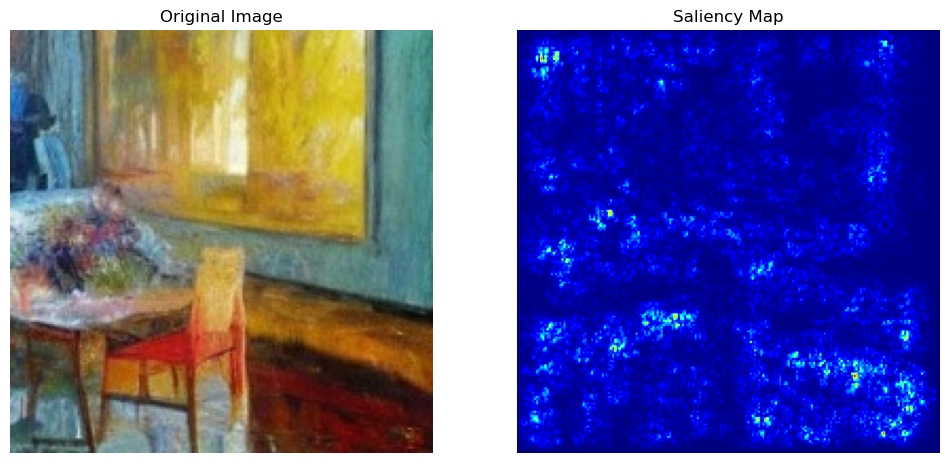

In [24]:
for images, labels in train_dataset.take(1):
    sample_image = images[0].numpy()  
    sample_label = labels[0].numpy()  
    break

if sample_label == 0:
    sample_label = 'Fake'
else:
    sample_label = 'Real'
print("Sample image label:", sample_label)

target_class = 0
display_saliency_map(model, sample_image, target_class)

### Refine model

In [ ]:
# residual block
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    # First convolution layer
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    # Second convolution layer
    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    # Adjust shortcut connection if dimensions differ
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1,
                          strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x



def create_model(input_shape=(200, 200, 3)):
    input_layer = Input(shape=input_shape)

    # 1st conv
    x = Conv2D(32, (3, 3), strides=1, padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # 1st residual set
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)
    x = MaxPooling2D((2, 2))(x)

    # 2nd residual set
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 128, stride=1)
    x = MaxPooling2D((2, 2))(x)

    # 3rd residual set
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 256, stride=1)

    # use global average pooling to reduce the spatial dimensions
    x = GlobalAveragePooling2D()(x)
    
    # fully connected layers
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)


    output_layer = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


model = create_model()
model.summary()

# callbacks
lr_plateau = ReduceLROnPlateau(
    monitor='val_loss',    
    factor=0.5,            
    patience=3,            
    verbose=1,
    min_lr=1e-6
)
early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=8,            
    restore_best_weights=True,
    verbose=1
)
checkpoint = ModelCheckpoint(
    filepath=f"{weigths_path}/art_best_model.h5",      
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# training
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,  
    callbacks=[lr_plateau, early_stop, checkpoint]
)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 200, 200, 3)]        0         []                            
                                                                                                  
 conv2d_2 (Conv2D)           (None, 200, 200, 32)         896       ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 200, 200, 32)         128       ['conv2d_2[0][0]']            
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 200, 200, 32)         0         ['batch_normalization[0]